In [1]:
import os
import copy
import torch
from pathlib import Path
from stCCL.stCCL.config import set_arg
from stCCL.stCCL.data import *
from stCCL.stCCL.utils import *
from stCCL.stCCL.stCCL import *
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt
from sklearn.metrics.cluster import adjusted_rand_score
from sklearn.metrics import normalized_mutual_info_score
from sklearn.metrics import homogeneity_score, completeness_score

In [2]:
os.environ['R_HOME'] = '/home/ZHX/anaconda3/envs/GraphST/lib/R'
current_path = os.getcwd()
print("当前路径：", current_path)
file_path=current_path
# gpu
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
# path
# data_root = Path('/home/ZHX/Dataset/DLPFC')
result_path = "/home/ZHX/code111/GraphST-main/final_result/stCCL_result/"
#设置参数
opt = set_arg()
arg = opt.parse_args(['--n_domain', '15','--radius','150','--latent_dim','30'])
print(arg)

当前路径： /home/ZHX/code111/GraphST-main/stCCL/Tutorial
Namespace(epoch=1000, hvg_n=3000, knn=6, latent_dim=30, log_step=10, lr=0.001, n_domain=15, n_refine=25, radius=150, seed=0, temp=0.05, weight_decay=0.0001)


In [3]:
sc.logging.print_header()
print(f"squidpy=={sq.__version__}")
# load the pre-processed dataset
img = sq.datasets.visium_hne_image()
adata = sq.datasets.visium_hne_adata()

## add ground truth
adata.obs['Ground Truth'] = adata.obs['cluster']

sample_name = 'cornal mouse brain'
print("=============原始{}切片信息，带ground truth===============".format(sample_name))
print(adata)


scanpy==1.9.8 anndata==0.9.2 umap==0.5.7 numpy==1.22.4 scipy==1.10.1 pandas==2.0.3 scikit-learn==1.3.2 statsmodels==0.14.1 igraph==0.11.8 louvain==0.8.2 pynndescent==0.5.13
squidpy==1.2.3
=============原始cornal mouse brain切片信息，带ground truth===============
AnnData object with n_obs × n_vars = 2688 × 18078
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'cluster', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', '

spatial graph(k) completed!
spatial graph(radius) completed!
start construct feature graph
feature graph completed!
Size of Input:  (2688, 4000)
AnnData object with n_obs × n_vars = 2688 × 18078
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'cluster', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'rank_genes_groups', 'spatial', 'umap', 'Ground Truth_colors'
    obsm: 'X_pca', 'X_umap', 

  0%|          | 1/1000 [00:00<06:22,  2.61it/s]

 epoch:  0  feat_loss = 1.65  loss_sl_1 = 17.68  loss_sl_2 = 0.00  total_loss = 5.19


 11%|█         | 111/1000 [00:01<00:08, 103.42it/s]

 epoch:  100  feat_loss = 0.19  loss_sl_1 = 0.47  loss_sl_2 = 0.09  total_loss = 0.30


...

 82%|████████▏ | 815/1000 [00:08<00:01, 106.06it/s]

 epoch:  800  feat_loss = 0.12  loss_sl_1 = 0.03  loss_sl_2 = 0.01  total_loss = 0.13


 91%|█████████▏| 914/1000 [00:09<00:00, 105.82it/s]

 epoch:  900  feat_loss = 0.12  loss_sl_1 = 0.03  loss_sl_2 = 0.01  total_loss = 0.13


100%|██████████| 1000/1000 [00:09<00:00, 101.84it/s]


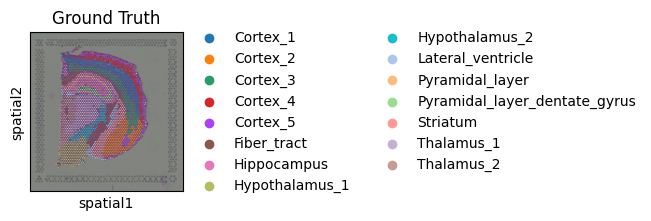

Completion of training


sh: warning: setlocale: LC_ALL: cannot change locale (en_US.UTF-8)
sh: warning: setlocale: LC_ALL: cannot change locale (en_US.UTF-8)
During startup - Warning messages:
1: Setting LC_CTYPE failed, using "C" 
2: Setting LC_COLLATE failed, using "C" 
3: Setting LC_TIME failed, using "C" 
4: Setting LC_MESSAGES failed, using "C" 
5: Setting LC_MONETARY failed, using "C" 
6: Setting LC_PAPER failed, using "C" 
7: Setting LC_MEASUREMENT failed, using "C" 
R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


/tmp/ipykernel_1628539/3253784180.py:28: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['ARI']=ARI


ARI = 0.6927
NMI = 0.7931
HS = 0.7811
CS = 0.8056


In [4]:
# # Plot ground truth
# plt.rcParams["figure.figsize"] = (5, 5)
sq.pl.spatial_scatter(adata, color="Ground Truth")

# #preprocessing
# sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=3000)
# sc.pp.normalize_total(adata, target_sum=1e4)
# sc.pp.log1p(adata)
# print("=============预处理后{}切片信息===============".format(sample_name))
# print(adata)

# train model
adata = train(adata,arg)
print("Completion of training")


## clustering
adata = mclust_R(adata, arg.n_domain,used_obsm='stCCL' )
# adata = mclust_R(adata, arg.n_domain,used_obsm='stCCL' ,refine=True)

# filter out NA nodes
adata = adata[~pd.isnull(adata.obs['Ground Truth'])]
ARI = adjusted_rand_score(adata.obs['mclust'], adata.obs['Ground Truth'])
NMI = normalized_mutual_info_score(adata.obs['mclust'], adata.obs['Ground Truth'])
HS = homogeneity_score(adata.obs['Ground Truth'],adata.obs['mclust'])
CS = completeness_score(adata.obs['Ground Truth'],adata.obs['mclust'])

adata.uns['ARI']=ARI
adata.uns['NMI']=NMI
adata.uns['HS']=HS
adata.uns['CS']=CS
print('ARI = %.4f' %ARI)
print('NMI = %.4f' %NMI)
print('HS = %.4f' %HS)
print('CS = %.4f' %CS)

/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/tools/_paga.py:121: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['paga'] = {}
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/tools/_paga.py:127: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[groups + '_sizes'] = np.array(paga.ns)
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No

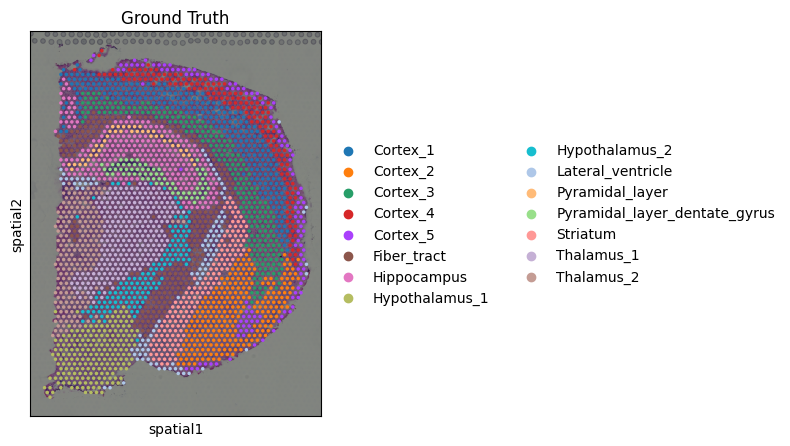

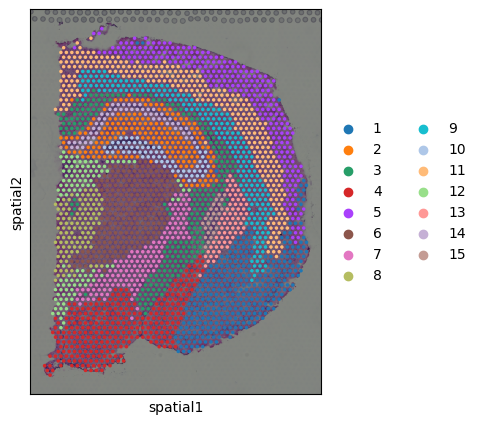

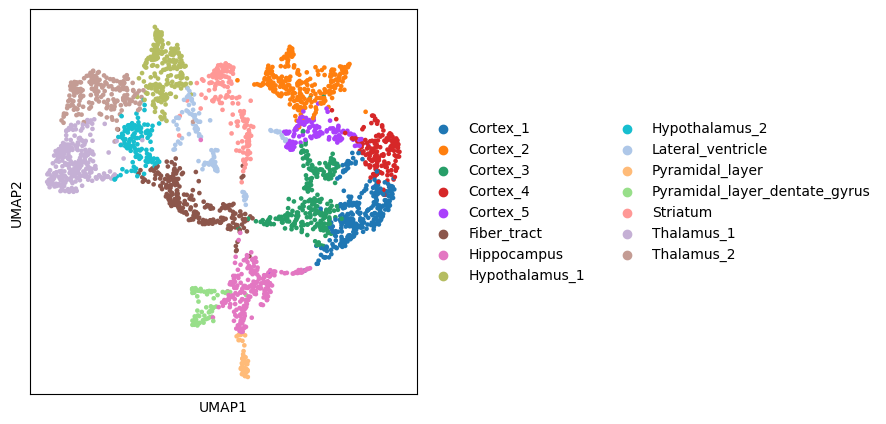

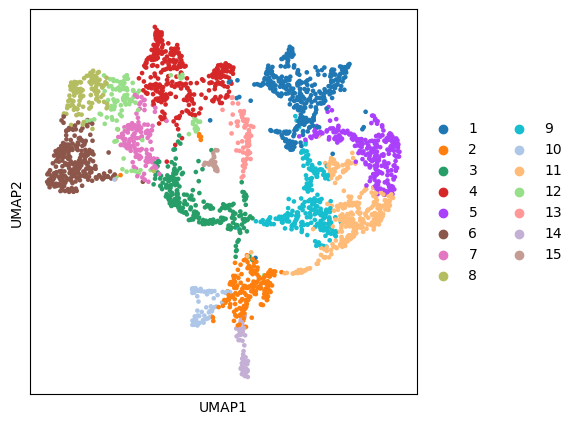

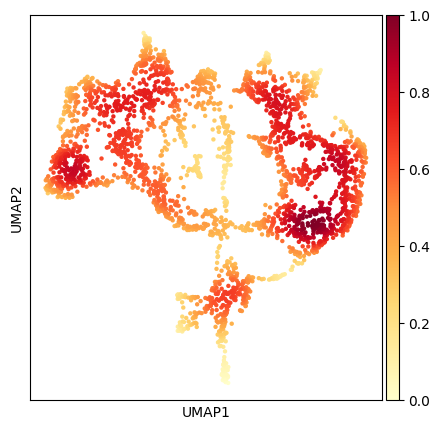

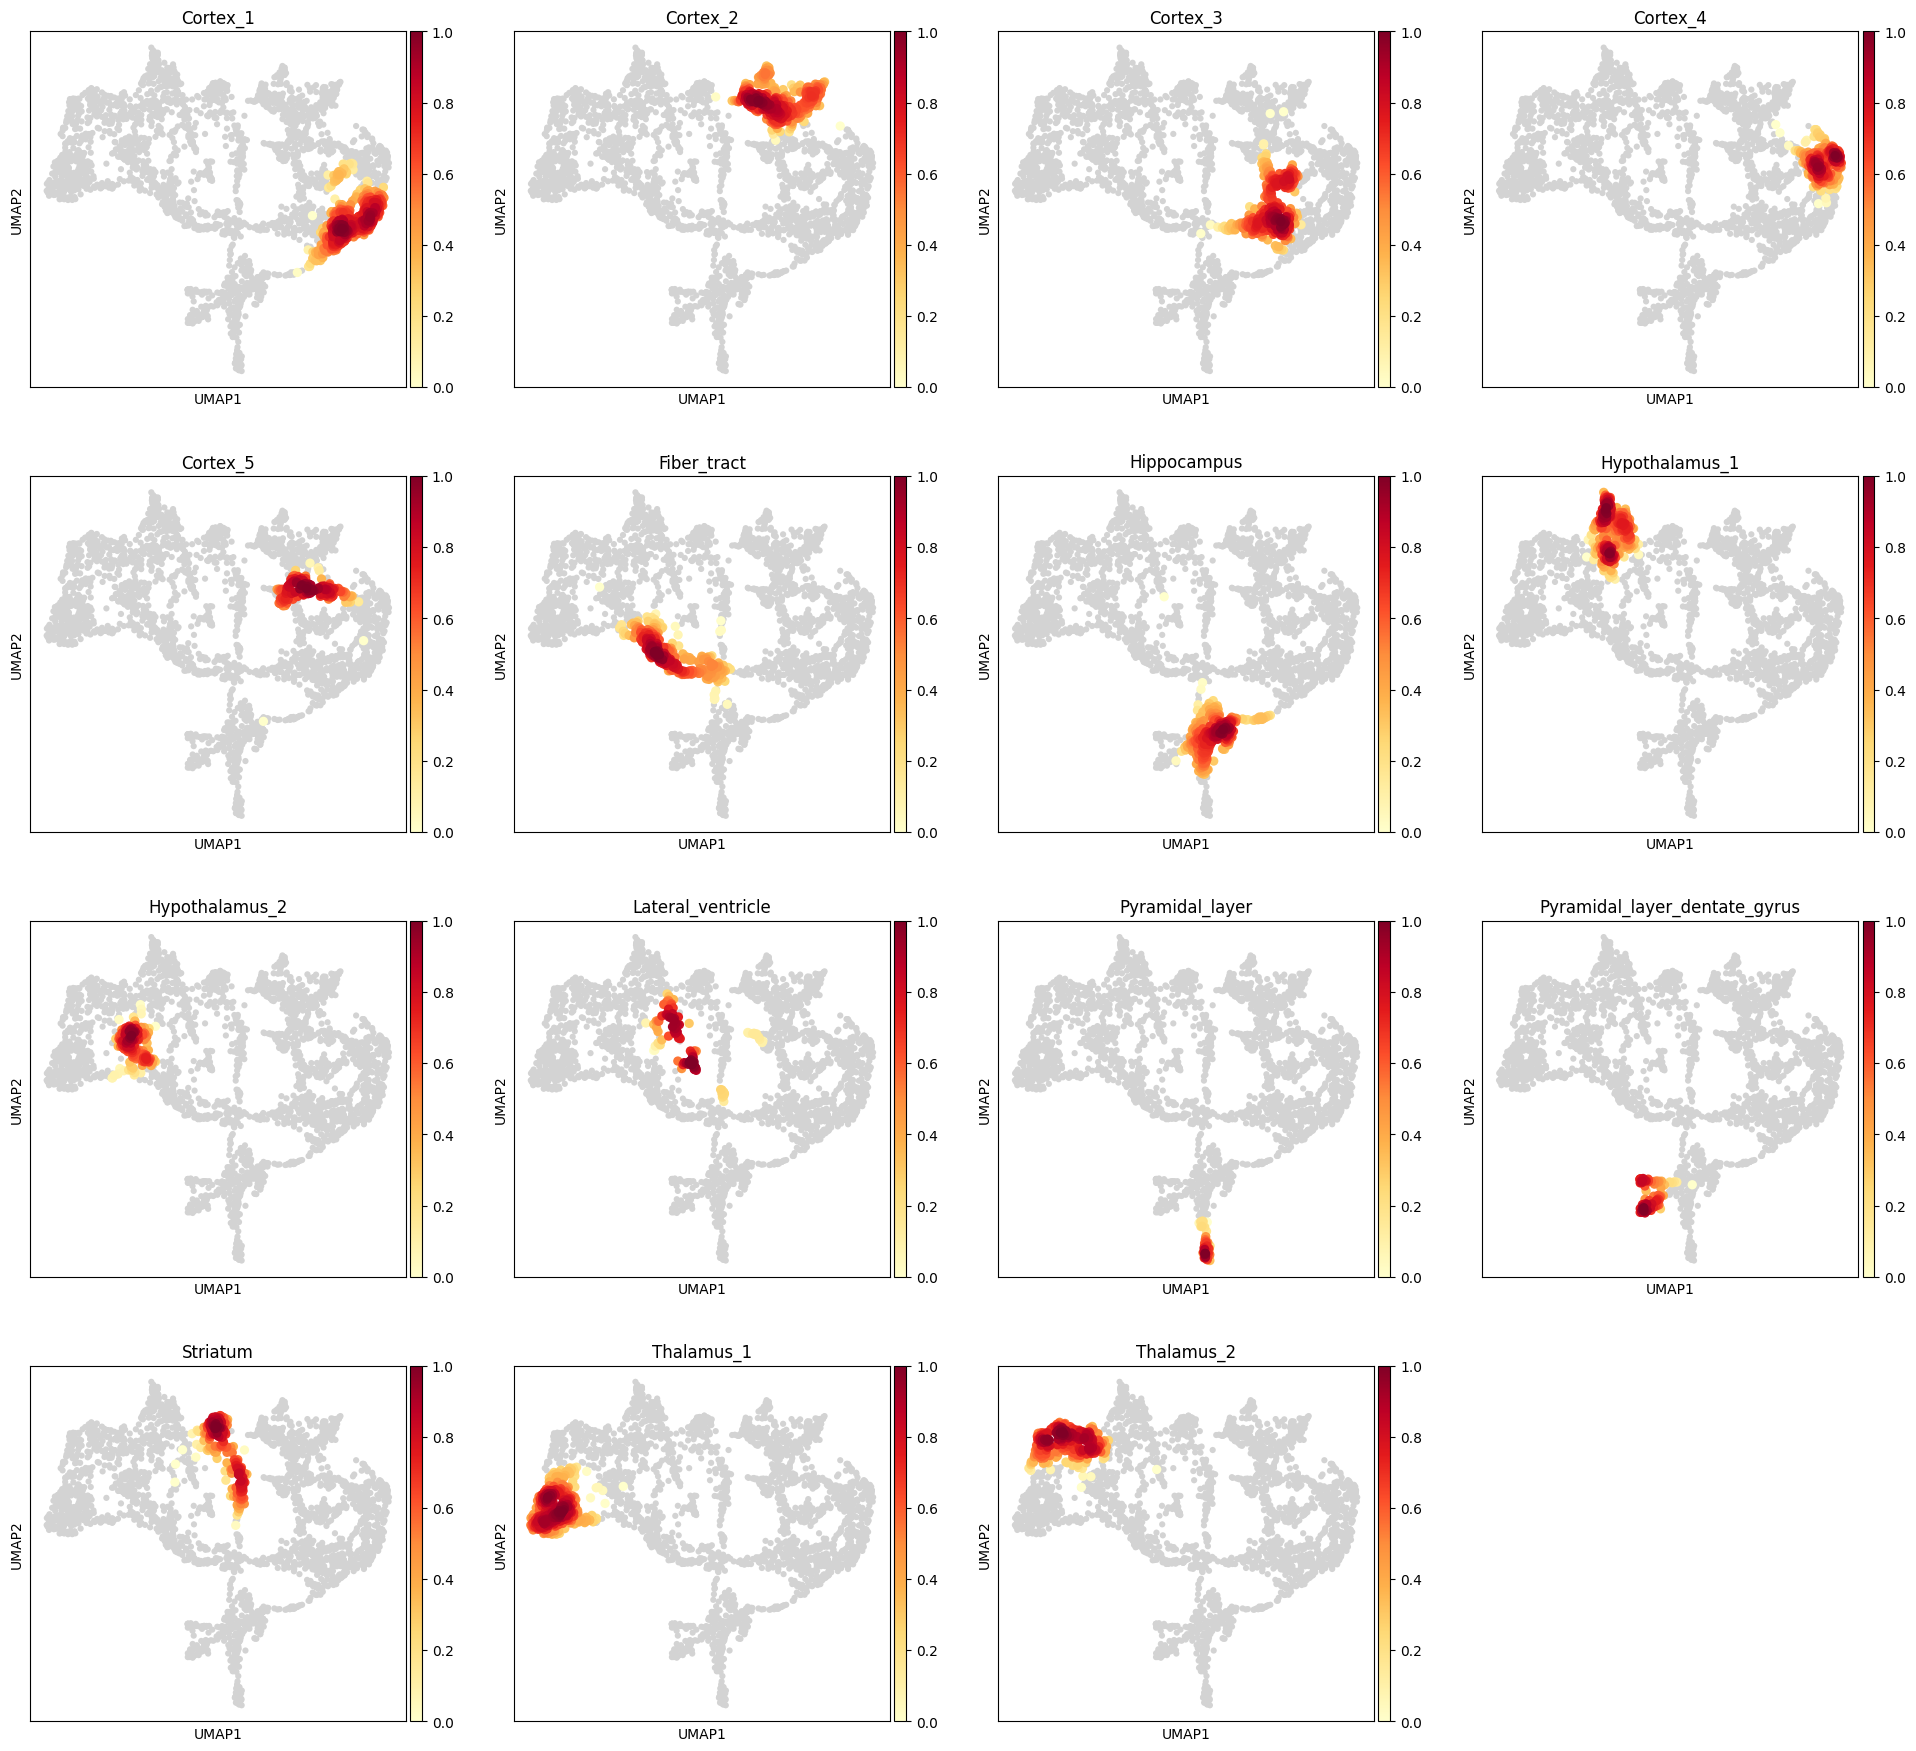

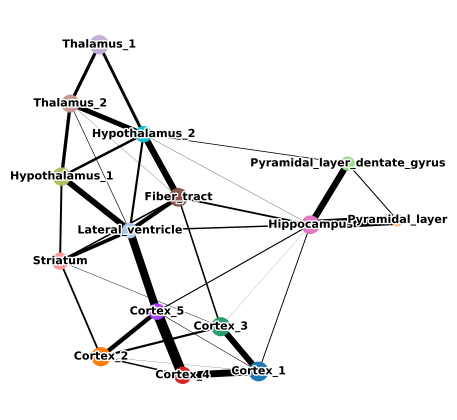

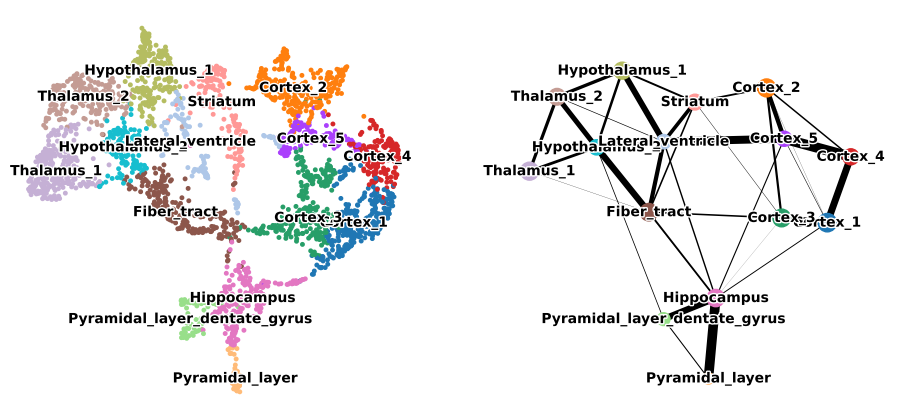

In [5]:
out_path = os.path.join(result_path , sample_name)
# 检查文件夹是否存在，如果不存在则创建文件夹
if not os.path.exists(out_path):
    os.makedirs(out_path)

## spatial architectures
plt.rcParams["figure.figsize"] = (5, 5)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'black'
sc.pl.spatial(adata,
                  img_key="hires",
                  color="Ground Truth",
                  frameon='True',
                  show=False)
plt.savefig(os.path.join(out_path,"{}_ground truth.png").format(sample_name),bbox_inches='tight',dpi=300)


plt.rcParams["figure.figsize"] = (5, 5)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'black'
sc.pl.spatial(adata,
                  img_key="hires",
                  color="mclust",
                  frameon='True',
                  title='',
                  # legend_loc='True',
                  show=False)
plt.savefig(os.path.join(out_path,"{}_ARI.png").format(sample_name),bbox_inches='tight',dpi=300)


# plotting predicted labels by UMAP
sc.pp.neighbors(adata, use_rep='stCCL')
sc.tl.umap(adata)
plt.rcParams["figure.figsize"] = (5, 5)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'black'
sc.pl.umap(adata,
               color="Ground Truth",
               title='',
           frameon='True',
               show=False)
plt.savefig(os.path.join(out_path,"{}_ground_truth_umap.png").format(sample_name),bbox_inches='tight',dpi=300)

plt.rcParams["figure.figsize"] = (5, 5)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'black'
sc.pl.umap(adata,
               color="mclust",
                title='',
           frameon='True',
               # legend_loc='True',
               show=False)
plt.savefig(os.path.join(out_path,"{}_umap.png").format(sample_name),bbox_inches='tight',dpi=300)


## heatmap of density
plt.rcParams["figure.figsize"] = (5, 5)
sc.tl.embedding_density(adata, basis='umap')
sc.pl.embedding_density(adata, basis='umap', fg_dotsize=40, show=False)
plt.savefig(os.path.join(out_path,"{}_heatmap of density.png").format(sample_name))

plt.rcParams["figure.figsize"] = (5, 5)
sc.tl.embedding_density(adata, basis='umap', groupby='Ground Truth')
sc.pl.embedding_density(adata, basis='umap', groupby='Ground Truth', show=False)
plt.savefig(os.path.join(out_path,"{}_heatmap of density_by_layer.png").format(sample_name))

## paga trajectory inference
adata = adata[adata.obs['Ground Truth'].notna(), :]
sc.tl.paga(adata, groups='Ground Truth')
plt.rcParams["figure.figsize"] = (5, 5)
# 绘制标准PAGA图 (替换了paga_compare)
sc.pl.paga(adata,show=False,  frameon=False, fontoutline=2, fontsize=8)
plt.savefig(os.path.join(out_path,"{}_paga.png").format(sample_name),bbox_inches='tight',dpi=300)

# plt.rcParams["figure.figsize"] = (5, 5)
# # 绘制标准PAGA图 (替换了paga_compare)
# sc.pl.paga(adata,show=False, fontsize=10,  fontoutline=2)
# plt.savefig(os.path.join(out_path,"{}_paga_frame.png").format(sample_name),bbox_inches='tight',dpi=300)

## paga trajectory inference
adata = adata[adata.obs['Ground Truth'].notna(), :]
sc.tl.paga(adata, groups='Ground Truth')
plt.rcParams["figure.figsize"] = (5, 5)
sc.pl.paga_compare(adata, legend_fontsize=10, frameon=False, size=50,
                   title='', legend_fontoutline=2, show=False)
plt.savefig(os.path.join(out_path,"{}_paga2.png").format(sample_name))
